## Importing Libraries

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(action='ignore')

## 1.  Import The CSv Data as Dataframe

In [28]:
df=pd.read_csv('data/student.csv')


## 2.Top  5 rows

In [29]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 2.2 Dataset Information

This dataset contains information about students, including:

    -> Gender: Whether the student is male or female
    -> Race/Ethnicity: The ethnic group of the student (Group A, B, C, D, or E)
    -> Parental Level of Education: The highest education level completed by the student's parents (bachelor’s degree, some college, master’s degree, associate degree, or high school)
    -> Lunch: Whether the student had a standard lunch or free/reduced lunch before the test
    -> Test Preparation Course: Whether the student completed the test preparation course or not
    -> Math Score: Marks scored in the math test
    -> Reading Score: Marks scored in the reading test
    -> Writing Score: Marks scored in the writing test

## 3. Data Checks to perform
• Check Missing values

• Check Duplicates

• Check data type

• Check the number of unique values of each column

• Check statistics of data set

• Check various categories present in the different categorical column

## 3.1 Check missing Values

In [30]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

There is no missing values in the data set

## 3.2 Check Duplicates Values

In [31]:
df.duplicated().sum()

np.int64(0)

There is no duplicated values in the data set

## 3.3 Check Data types

In [32]:
df.dtypes

gender                           str
race_ethnicity                   str
parental_level_of_education      str
lunch                            str
test_preparation_course          str
math_score                     int64
reading_score                  int64
writing_score                  int64
dtype: object

## 3.4 Check the number of uniques values of each column

In [33]:
feature_name= df.columns

for col in feature_name:
    print(col.title() ,f"have { df[col].nunique()} number of unique values")
    print()

Gender have 2 number of unique values

Race_Ethnicity have 5 number of unique values

Parental_Level_Of_Education have 6 number of unique values

Lunch have 2 number of unique values

Test_Preparation_Course have 2 number of unique values

Math_Score have 81 number of unique values

Reading_Score have 72 number of unique values

Writing_Score have 77 number of unique values



## 3.5 Check Statistic of data set

In [34]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Insights

    • From above description of numerical data, all means are very close to each other - between 66 and 68.05;
    • All standard deviations are also close - between 14.6 and 15.19;
    • While there is a minimum score 0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17 


## 3.6 Check various categories present in the different categorical column

In [35]:
# category_features =
category_features= df.select_dtypes(include='object').columns.tolist()

for i in category_features:
    print(i , f"contain {df[i].nunique() } values [{df[i].unique()}]")
    print()

gender contain 2 values [<StringArray>
['female', 'male']
Length: 2, dtype: str]

race_ethnicity contain 5 values [<StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str]

parental_level_of_education contain 6 values [<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str]

lunch contain 2 values [<StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str]

test_preparation_course contain 2 values [<StringArray>
['none', 'completed']
Length: 2, dtype: str]



In [36]:
numerical_features= df.select_dtypes(exclude='O').columns.tolist()
print("Numerical features")
for i in numerical_features:
    print(i)

Numerical features
math_score
reading_score
writing_score


## 3.8 Adding a columns for Total Score and Average

In [37]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [38]:
df["Total_Score"]= df["math_score"]+df["reading_score"]+df["writing_score"]
df["Average"]= (df["Total_Score"]/3)
df.head()


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [39]:
reading_full =df[df['reading_score']==100].shape[0]
math_full =df[df['math_score']==100].shape[0]
write_full =df[df['writing_score']==100].shape[0]


In [40]:
print("Number of students with full marks in Math:",math_full)
print("Number of students with full marks in Reading:",reading_full)
print("Number of students with full marks in Write:",write_full)


Number of students with full marks in Math: 7
Number of students with full marks in Reading: 17
Number of students with full marks in Write: 14


In [41]:
reading_less_20 =df[df['reading_score']<=20].shape[0]
math_less_20 =df[df['math_score']<=20].shape[0]
write_less_20 =df[df['writing_score']<=20].shape[0]


In [42]:
print("Number of students with less than 20 marks in Math:",math_less_20)
print("Number of students with less than 20 marks in Reading:",reading_less_20)
print("Number of students with less than 20 marks in Write:",write_less_20)


Number of students with less than 20 marks in Math: 4
Number of students with less than 20 marks in Reading: 1
Number of students with less than 20 marks in Write: 3


Insights 

    From the above we get the studens have performed best and worst on each subject

## 4. Exploring Data (Visualization)

## 4.1 Visualsize average score distribution to make some conclusion.

-> Histogram

-> Kernel Distribution Function (KDE)

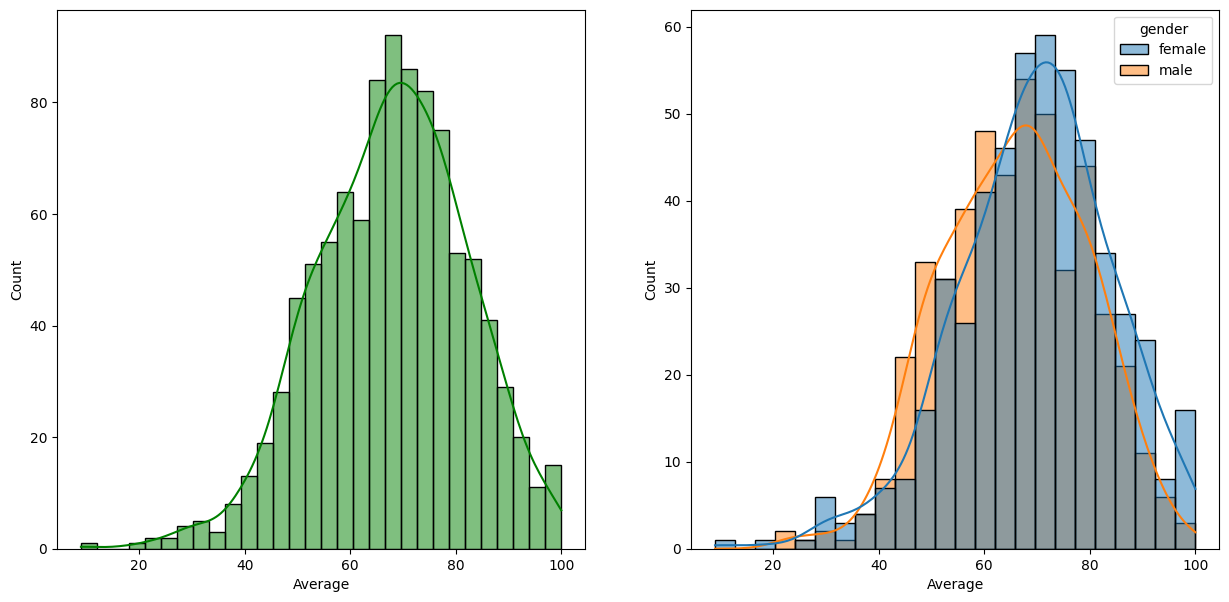

In [43]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='Average', bins=30, kde=True, color='g') 
plt.subplot(122)
sns.histplot(data=df, x='Average',kde=True,  hue="gender") 
plt.show()

Insight

Female students tend to perform well than male students

In [44]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


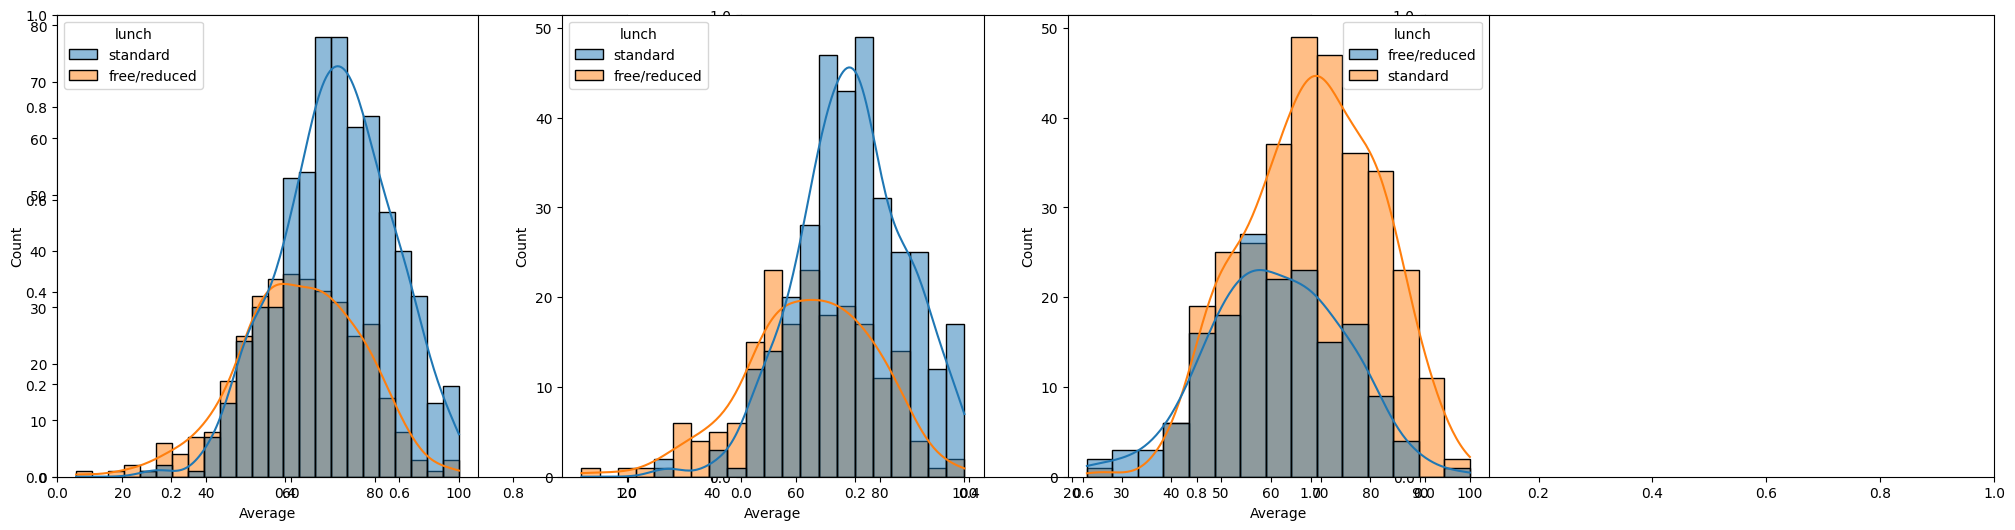

In [45]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='Average',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='Average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='Average',kde=True,hue='lunch')
plt.show()

Insights

    Standard lunch helps perform well in exams 
    Standard lunch helps perform well exams be it a male or a female
    

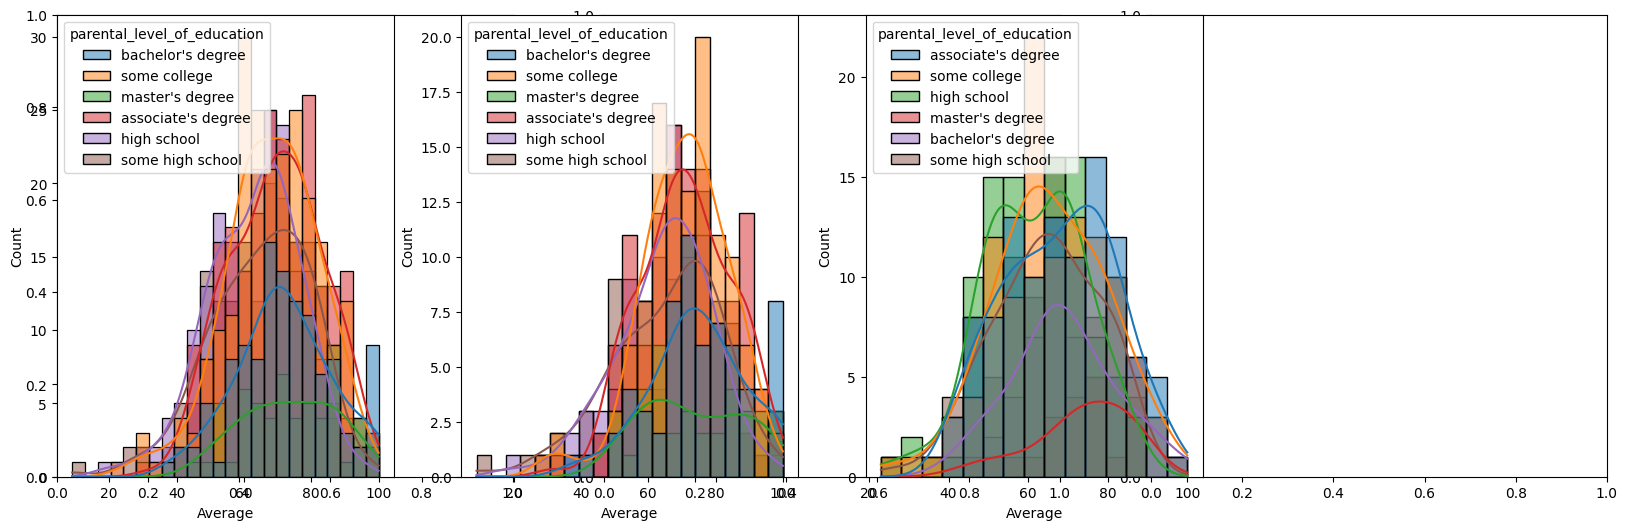

In [46]:
plt.subplots(1,3,figsize=(20,6))
plt.subplot(141)
sns.histplot(data=df, x='Average', kde=True, hue='parental_level_of_education')
plt.subplot(142)
sns.histplot(data=df[df['gender']=='female'], x='Average', kde=True, hue='parental_level_of_education')

plt.subplot(143)
sns.histplot(data=df[df['gender']=='male'],x='Average', kde=True, hue='parental_level_of_education')
plt.show()


#####  Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot we can see there is no effect of parent's education on female students.
- 3rd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam


#### 4.2 Maximumum score of students in all three subjects

In [47]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


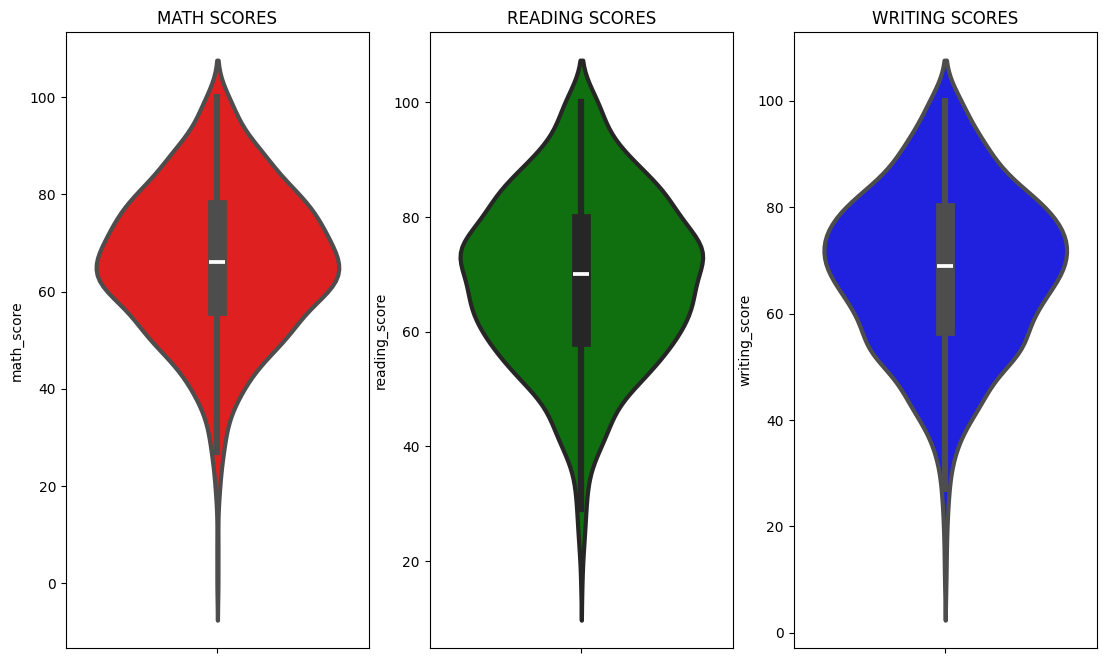

In [48]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

#### Insights
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80